# Static XAS 5 mmol

Downstream analysis for processed static-XAS H5 data. Raw processing stays in `compute_static_xas.py`; this notebook tunes GMD filtering, shot center assignment, double-peak rejection, and XAS (gmd/vls) plots against nominal and converted photon energy.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / 'analysis' / 'scripts').exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError('Could not locate repository root.')

scripts_dir = repo_root / 'analysis' / 'scripts'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

import config as path_config
import static_xas_analysis as sxa

In [21]:
ANALYSIS_PARAMS = {
    'RUN_NO': 58794,
    'INPUT_H5': Path(path_config.COMBINED_DIR).parent / 'xas_static' / 'run58794_static_xas.h5',
    #'GMD_EDGES': np.array([0.0, 1.6, 3.2, 6.4, 12.8]),
    'GMD_EDGES': np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]),
    'GMD_MIN_THRESHOLD': None,  # set to a number to reject GMD below this value
    'GMD_MAX_THRESHOLD': 10.0,  # set to None to disable the high-GMD filter
    'VLS_INTENSITY_THRESHOLD': 1000,
    'CENTER_METHOD': 'com',  # 'com', 'peak', 'smooth_peak'/'peak_smooth', or 'gaussian_logfit'
    'CENTER_HALF_WINDOW': 5,  # non-peak centers use strongest-peak +/- this many pixels
    'CENTER_CHUNK_SIZE': 50000,
    'PROXY_PIXEL_BIN_WIDTH': 1,  # pixel-proxy bin width, in Gotthard pixels
    'REJECT_DOUBLE_PEAKS': True,
    'DOUBLE_PEAK_KWARGS': {
        'min_distance_px': 3,
        'max_distance_px': 17,
        'min_prom_sigma': 2.5,
        'min_height_sigma': 2.0,
        'min_rel_peak_height': 0.35,
        'min_second_ratio': 0.05,
        'min_bridge_drop': 0.015,
        'min_split_sigma': 0.75,
    },
    'N_DOUBLE_PEAK_EXAMPLES': 12,
    'N_LOW_GMD_EXAMPLES': 12,
    'N_HIGH_GMD_EXAMPLES': 12,
    'CALIBRATION_NOMINAL_ENERGY_EV': 284.0,
    'CALIBRATION_PIXEL_ROI': None,  # absolute Gotthard pixel range, e.g. (510, 540)
    'PIXEL_MAP_CONFIG': {
        'source_to_grating_m': 0.85,
        'grating_to_screen_m': 0.5429,
        'incident_angle_deg': 86.78,
        'groove_density_lines_per_mm': 1200.0,
        'diffraction_order': 1,
        'magnification': 3.0,
        'pixel_pitch_m': 50e-6,
        'axis_sign': 1,
    },
    'PIXEL_MAP_CALIBRATION': {
        'pixel': 524.0,
        'energy_eV': 284.2,
    },
    'INVERSE_MAP_RANGE_EV': (260.0, 290.0),
    'INVERSE_MAP_SAMPLES': 10000,
    'YLIM': (0, 3.0e-4),
}
ANALYSIS_PARAMS['LOW_GMD_PLOT_THRESHOLD'] = ANALYSIS_PARAMS['GMD_MIN_THRESHOLD']
ANALYSIS_PARAMS['HIGH_GMD_PLOT_THRESHOLD'] = ANALYSIS_PARAMS['GMD_MAX_THRESHOLD']

globals().update(ANALYSIS_PARAMS)
INPUT_H5 = Path(INPUT_H5)

print(f'input file            : {INPUT_H5}')
print(f'gmd edges             : {GMD_EDGES}')
print(f'gmd min threshold     : {GMD_MIN_THRESHOLD}')
print(f'gmd max threshold     : {GMD_MAX_THRESHOLD}')
print(f'vls threshold         : {VLS_INTENSITY_THRESHOLD}')
print(f'center method         : {CENTER_METHOD}')
print(f'center half-window    : {CENTER_HALF_WINDOW} pixels')
print(f'proxy pixel bin width : {PROXY_PIXEL_BIN_WIDTH}')
print(f'reject double peaks   : {REJECT_DOUBLE_PEAKS}')


input file            : /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/xas_static/run58794_static_xas.h5
gmd edges             : [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
gmd min threshold     : None
gmd max threshold     : 10.0
vls threshold         : 1000
center method         : com
center half-window    : 5 pixels
proxy pixel bin width : 1
reject double peaks   : True


In [3]:
if not INPUT_H5.exists():
    raise FileNotFoundError(f'Missing processed static-XAS file: {INPUT_H5}')

run = sxa.load_static_xas_run(INPUT_H5)
print(f"loaded run             : {run.attrs.get('run_no')}")
print(f"loaded shape           : {run.vls.shape}")
print(f"nominal energy range   : {run.nominal_energies[0]:.2f} .. {run.nominal_energies[-1]:.2f} eV")
print(f"total stored shots     : {run.stored_shots}")
print(f"vls crop roi           : {run.attrs.get('vls_crop_roi')}")
print(f"signal bunch range     : {run.attrs.get('signal_bunch_range')}")

loaded run             : 58794
loaded shape           : (31, 102720, 200)
nominal energy range   : 286.00 .. 271.00 eV
total stored shots     : 1164240
vls crop roi           : [450 650]
signal bunch range     : [10 40]


## Calibration Quicklook

requested nominal energy : 284.000 eV
selected nominal energy  : 284.000 eV
energy index             : 4
finite shots used        : 35790
peak pixel               : 520.25
peak intensity           : 471


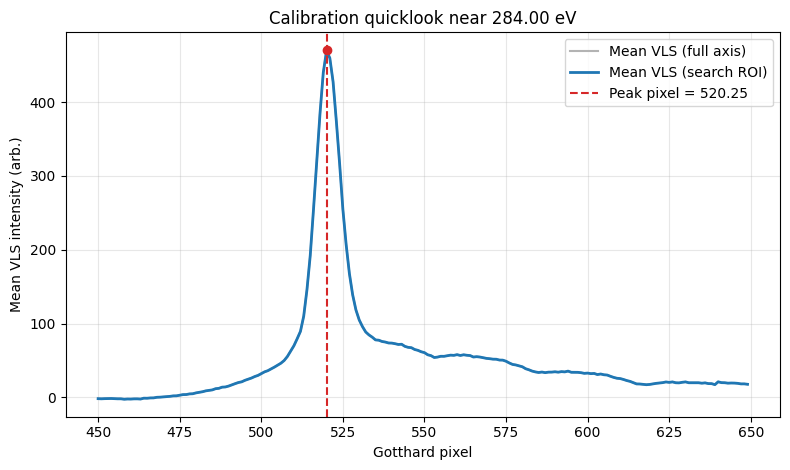

In [4]:
cal = sxa.calibration_peak_summary(
    run,
    CALIBRATION_NOMINAL_ENERGY_EV,
    pixel_roi=CALIBRATION_PIXEL_ROI,
)
print(f"requested nominal energy : {cal['requested_energy_eV']:.3f} eV")
print(f"selected nominal energy  : {cal['selected_energy_eV']:.3f} eV")
print(f"energy index             : {cal['energy_index']}")
print(f"finite shots used        : {cal['shots_used']}")
print(f"peak pixel               : {cal['peak_pixel']:.2f}")
print(f"peak intensity           : {cal['peak_value']:.3g}")
sxa.plot_calibration_peak(cal)
plt.show()

## Build Filtered Actual-Energy XAS

In [22]:
nominal = sxa.bin_nominal_energy_run(
    run,
    GMD_EDGES,
    vls_intensity_threshold=VLS_INTENSITY_THRESHOLD,
    gmd_min_threshold=GMD_MIN_THRESHOLD,
    gmd_max_threshold=GMD_MAX_THRESHOLD,
)

shots = sxa.prepare_proxy_shots(
    run,
    vls_intensity_threshold=VLS_INTENSITY_THRESHOLD,
    gmd_min_threshold=GMD_MIN_THRESHOLD,
    gmd_max_threshold=GMD_MAX_THRESHOLD,
    center_method=CENTER_METHOD,
    center_half_window=CENTER_HALF_WINDOW,
    center_chunk_size=CENTER_CHUNK_SIZE,
    reject_double_peaks=REJECT_DOUBLE_PEAKS,
    double_peak_kwargs=DOUBLE_PEAK_KWARGS,
)
proxy = sxa.bin_proxy_energy(
    shots,
    run.vls_pixels,
    GMD_EDGES,
    pixel_bin_width=PROXY_PIXEL_BIN_WIDTH,
)
actual_energy, pixel_map_cfg, pixel_map_cal = sxa.convert_binned_pixels_to_energy(
    proxy,
    PIXEL_MAP_CONFIG,
    PIXEL_MAP_CALIBRATION,
    INVERSE_MAP_RANGE_EV,
    INVERSE_MAP_SAMPLES,
)

print(sxa.format_shot_summary(shots, 'filtered'))
print(f'proxy bins             : {proxy.x.size}')
print(f'converted energy range : {np.nanmin(actual_energy.x):.3f} .. {np.nanmax(actual_energy.x):.3f} eV')
print(f'pixel-map magnification: {pixel_map_cfg.magnification}')
print(f'calibration anchor     : pixel {pixel_map_cal.pixel:.1f} -> {pixel_map_cal.energy_eV:.3f} eV')


filtered: finite=776160, after peak=397350, after GMD range=386844, high-GMD removed=10506, double rejected=33, after double=386811, after center=386811, final=386811, center=com
proxy bins             : 74
converted energy range : 271.915 .. 285.709 eV
pixel-map magnification: 3.0
calibration anchor     : pixel 524.0 -> 284.200 eV


## Low-GMD Spectra


In [6]:
if LOW_GMD_PLOT_THRESHOLD is not None:
    sxa.plot_low_gmd_spectra(
        run,
        LOW_GMD_PLOT_THRESHOLD,
        vls_intensity_threshold=VLS_INTENSITY_THRESHOLD,
        n_examples=N_LOW_GMD_EXAMPLES,
    )
    plt.show()
else:
    print('LOW_GMD_PLOT_THRESHOLD is None; low-GMD spectrum plot skipped.')


LOW_GMD_PLOT_THRESHOLD is None; low-GMD spectrum plot skipped.


## High-GMD Spectra

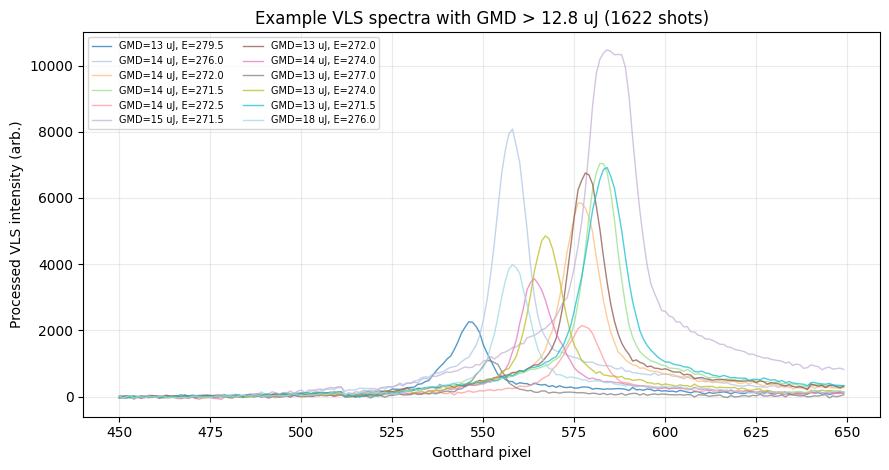

In [7]:
if HIGH_GMD_PLOT_THRESHOLD is not None:
    sxa.plot_high_gmd_spectra(
        run,
        HIGH_GMD_PLOT_THRESHOLD,
        vls_intensity_threshold=VLS_INTENSITY_THRESHOLD,
        n_examples=N_HIGH_GMD_EXAMPLES,
    )
    plt.show()
else:
    print('HIGH_GMD_PLOT_THRESHOLD is None; high-GMD spectrum plot skipped.')

## Double-Peak Spectra

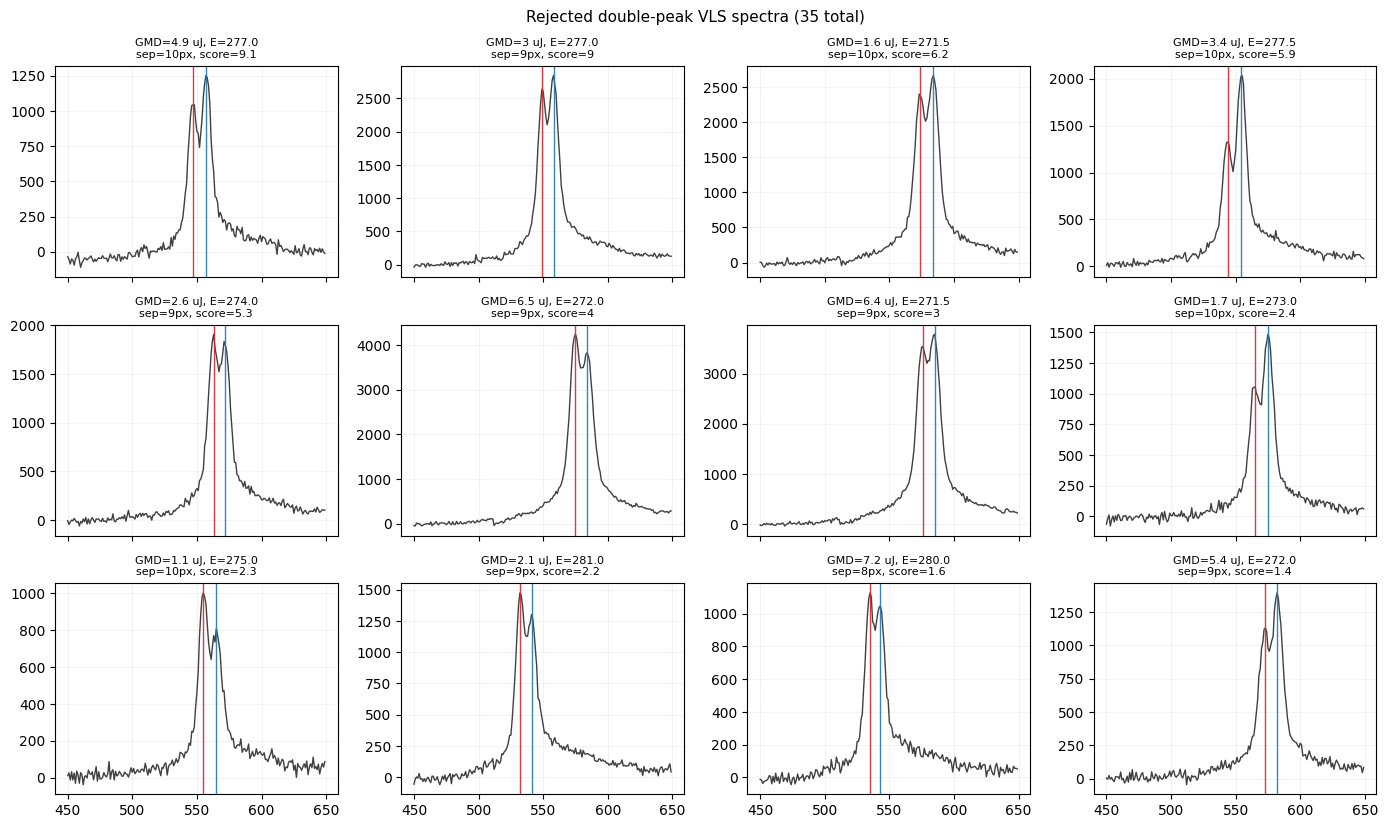

In [8]:
sxa.plot_double_peak_examples(
    shots,
    run.vls_pixels,
    n_examples=N_DOUBLE_PEAK_EXAMPLES,
)
plt.show()

## XAS Curves

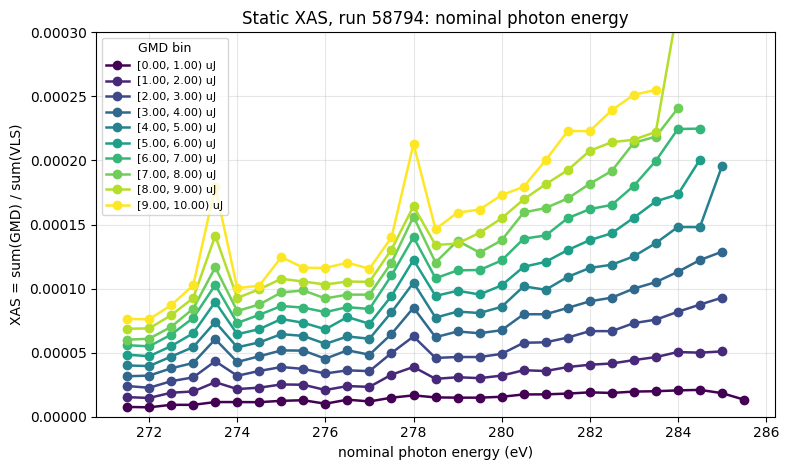

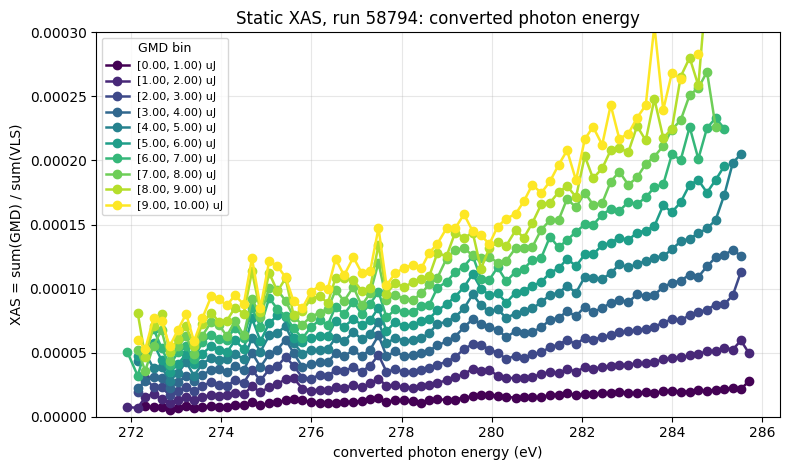

In [23]:
sxa.plot_xas_curves(
    nominal,
    title=f'Static XAS, run {RUN_NO}: nominal photon energy',
    ylim=YLIM,
    marker='o',
)
plt.show()

sxa.plot_xas_curves(
    actual_energy,
    title=f'Static XAS, run {RUN_NO}: converted photon energy',
    ylim=YLIM,
    marker='o',
)
plt.show()